In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Input data files are available in the data directory
import os
print("Current directory: ", os.getcwd())
print("Files in data directory: ", os.listdir('data'))

Current directory:  d:\jupyter_notebook\experiments\Kaggle\Titanic - Machine Learning from Disaster
Files in data directory:  ['gender_submission.csv', 'test.csv', 'train.csv']


In [2]:
# Load training and test data
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/test.csv")

# Display first few rows of training data
print("Training data shape: ", train_data.shape)
print("Test data shape: ", test_data.shape)

train_data.head()

Training data shape:  (891, 12)
Test data shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Data analysis and missing value check
print("Training data info:")
train_data.info()

print("Missing values in training data:")
print(train_data.isnull().sum())

print("Missing values in test data:")
print(test_data.isnull().sum())

Training data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Missing values in training data:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
C

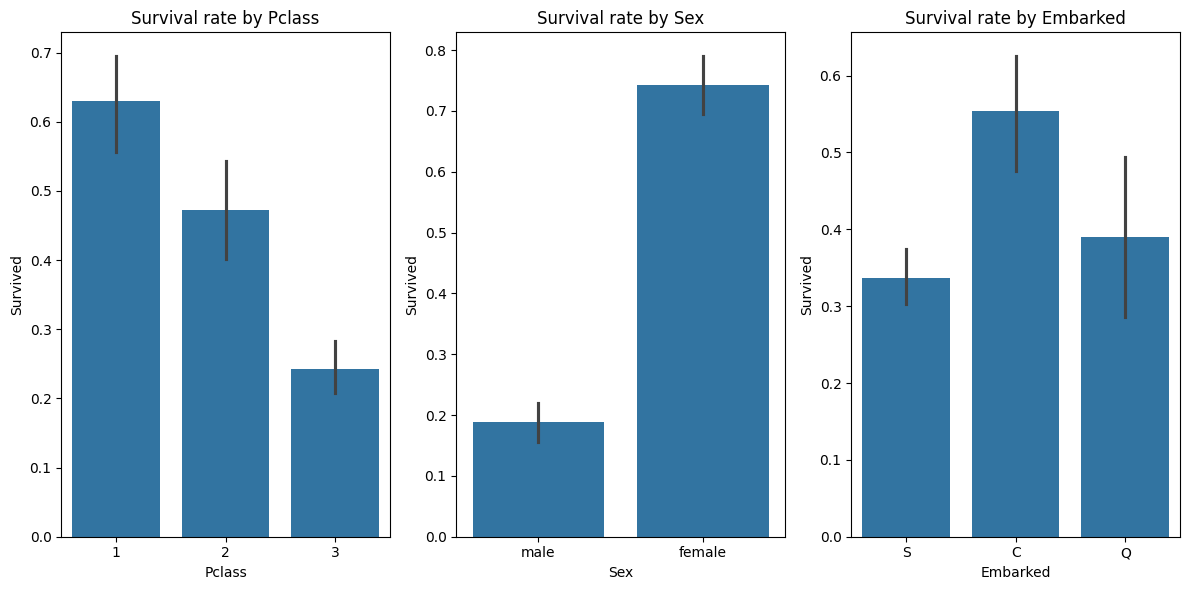

In [5]:
# EDA: Survival rate by different features
plt.figure(figsize=(12, 6))

# Survival rate by Pclass
plt.subplot(1, 3, 1)
sns.barplot(x='Pclass', y='Survived', data=train_data)
plt.title('Survival rate by Pclass')

# Survival rate by Sex
plt.subplot(1, 3, 2)
sns.barplot(x='Sex', y='Survived', data=train_data)
plt.title('Survival rate by Sex')

# Survival rate by Embarked
plt.subplot(1, 3, 3)
sns.barplot(x='Embarked', y='Survived', data=train_data)
plt.title('Survival rate by Embarked')

plt.tight_layout()
plt.show()

In [7]:
# Feature engineering function
def feature_engineering(df):
    # Create new features
    # Family size
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    
    # Is alone
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # Extract title from Name
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    
    # Group rare titles
    rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    
    # Extract cabin letter
    df['CabinLetter'] = df['Cabin'].str[0]
    df['CabinLetter'] = df['CabinLetter'].fillna('Unknown')
    
    # Fare binning
    df['FareBin'] = pd.qcut(df['Fare'], 4, labels=False)
    
    # Age binning
    df['AgeBin'] = pd.cut(df['Age'], 5, labels=False)
    
    return df

# Apply feature engineering
train_data = feature_engineering(train_data)
test_data = feature_engineering(test_data)

print("Training data after feature engineering: ")
train_data.head()

Training data after feature engineering: 


<>:11: SyntaxWarning: invalid escape sequence '\.'
<>:11: SyntaxWarning: invalid escape sequence '\.'
C:\Users\14983\AppData\Local\Temp\ipykernel_101924\4289832324.py:11: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Title,CabinLetter,FareBin,AgeBin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,Mr,Unknown,0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Mrs,C,3,2.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,Miss,Unknown,1,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Mrs,C,3,2.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,Mr,Unknown,1,2.0


In [8]:
# Define features for modeling
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'CabinLetter', 'IsAlone']

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

# Prepare data
X = train_data.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin', 'FareBin', 'AgeBin'], axis=1)
y = train_data['Survived']
X_test = test_data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'FareBin', 'AgeBin'], axis=1)

# Split data for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Test multiple models
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier()
}

# Evaluate models
results = {}
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Cross-validation
    cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
    results[name] = cv_scores.mean()
    print(f'{name}: {cv_scores.mean():.4f} (std: {cv_scores.std():.4f})')

# Best model
best_model_name = max(results, key=results.get)
print(f'Best model: {best_model_name} with accuracy: {results[best_model_name]:.4f}')

Random Forest: 0.8013 (std: 0.0288)
Gradient Boosting: 0.8305 (std: 0.0193)
SVM: 0.8350 (std: 0.0222)
KNN: 0.8160 (std: 0.0316)
Best model: SVM with accuracy: 0.8350


In [11]:
# Hyperparameter tuning for Random Forest
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7, 9],
    'model__min_samples_split': [2, 4, 6],
    'model__min_samples_leaf': [1, 2, 3]
}

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X, y)

print('Best parameters:', grid_search.best_params_)
print('Best cross-validation score:', grid_search.best_score_)

Best parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best cross-validation score: 0.8349883874207521


In [14]:
# Train best model on full dataset
best_pipeline = grid_search.best_estimator_
best_pipeline.fit(X, y)

# Evaluate on validation set
y_pred = best_pipeline.predict(X_val)
print('Validation accuracy:', accuracy_score(y_val, y_pred))
print('Confusion matrix:')
print(confusion_matrix(y_val, y_pred))
print('Classification report:')
print(classification_report(y_val, y_pred))

Validation accuracy: 0.8324022346368715
Confusion matrix:
[[92 13]
 [17 57]]
Classification report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.83      0.83      0.83       179



In [15]:
# Make predictions on test data
predictions = best_pipeline.predict(X_test)

# Create submission file
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print('Your submission was successfully saved!')
print('Submission shape:', output.shape)
output.head()

Your submission was successfully saved!
Submission shape: (418, 2)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
